## Load Feature from Metadata into Athena

In [12]:
import boto3

sm = boto3.client("sagemaker")
fgl = sm.list_feature_groups()

for fg in fgl["FeatureGroupSummaries"]:
    print(f"{fg['FeatureGroupName']} — Created: {fg['CreationTime']}")


neighborhood-feature-group — Created: 2025-05-29 01:31:27.239000+00:00
diabetes-feature-group-1750440114 — Created: 2025-06-20 17:21:54.675000+00:00
diabetes-feature-group-1750389317 — Created: 2025-06-20 03:15:17.759000+00:00
diabetes-feature-group-1750382712 — Created: 2025-06-20 01:25:12.539000+00:00
diabetes-feature-group-1750376734 — Created: 2025-06-19 23:45:34.836000+00:00
diabetes-feature-group-1750376310 — Created: 2025-06-19 23:38:30.991000+00:00
diabetes-feature-group-1750375180 — Created: 2025-06-19 23:19:40.947000+00:00
diabetes-feature-group-1750366956 — Created: 2025-06-19 21:02:36.718000+00:00
diabetes-feature-group — Created: 2025-06-19 20:49:07.625000+00:00


In [ ]:
# !!! RUN THIS ONLY IF YOU HAVE SUCCESSFULLY INGESTED THE FEATURE GROUP, ELSE UNCOMMENT AND RUN NEXT CELL 
# TO USE LOCAL DATA

import json
import awswrangler as wr

# Load saved metadata
with open("featurestore_metadata.json", "r") as f:
    metadata = json.load(f)

# Extract table and database info
athena_table = metadata["athena_table_name"]
athena_db = "sagemaker_featurestore"

# Construct and run query
query = f'SELECT * FROM "{athena_db}"."{athena_table}"'
print(f"[INFO] Running Athena query:\n{query}")

athena_df = wr.athena.read_sql_query(
    sql=query,
    database=athena_db,
    ctas_approach=False
)

# Copy to local variable for manipulation
data = athena_df.copy()
print(f"[INFO] Loaded data from Athena. Shape: {data.shape}")


In [1]:
# FOR FASTER CODE DEVELOPMENT, UNCOMMENT THIS

import pandas as pd

data = pd.read_pickle("data/cleaned_data.pkl")
print(f"Loaded data from local pickle file: {data.shape}")

# Rename to match Athena column naming convention
if "A1Cresult" in data.columns:
    data.rename(columns={"A1Cresult": "a1cresult"}, inplace=True)


Loaded data from local pickle file: (101766, 53)


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   RecordID                  101766 non-null  int64 
 1   encounter_id              101766 non-null  int64 
 2   patient_nbr               101766 non-null  int64 
 3   race                      101766 non-null  object
 4   gender                    101766 non-null  object
 5   age                       101766 non-null  object
 6   weight                    101766 non-null  object
 7   admission_type_id         101766 non-null  int64 
 8   discharge_disposition_id  101766 non-null  int64 
 9   admission_source_id       101766 non-null  int64 
 10  time_in_hospital          101766 non-null  int64 
 11  payer_code                101766 non-null  object
 12  medical_specialty         101766 non-null  object
 13  num_lab_procedures        101766 non-null  int64 
 14  num_

## Feature Engineering

In [2]:
## Fix NaNs

# Use lowercase 'a1cresult' due to Athena conversion
glu_order = ["None", "Norm", ">200", ">300"]
a1c_order = ["None", "Norm", ">7", ">8"]

glu_order_with_missing = ["missing"] + glu_order
a1c_order_with_missing = ["missing"] + a1c_order

data['max_glu_serum'] = (
    pd.Categorical(data['max_glu_serum'].fillna("missing"),
                   categories=glu_order_with_missing,
                   ordered=True)
    .astype(str)
)

data['a1cresult'] = (
    pd.Categorical(data['a1cresult'].fillna("missing"),
                   categories=a1c_order_with_missing,
                   ordered=True)
    .astype(str)
)


  readmitted  readmitted_flag
0         NO                0
1        >30                0
2         NO                0
3         NO                0
4         NO                0


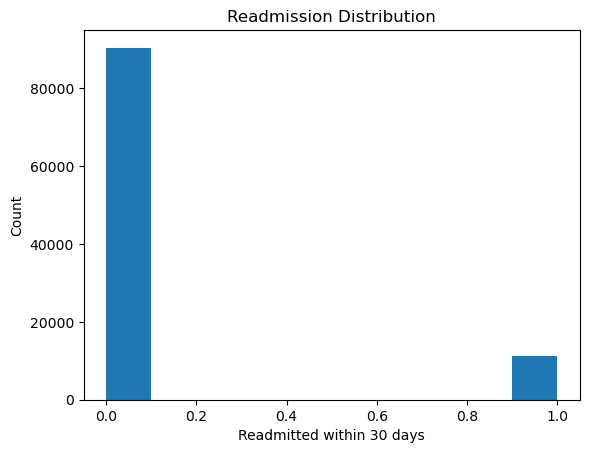

In [3]:
# Readmitted flag for binary classification

import matplotlib.pyplot as plt

data['readmitted_flag'] = data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
print(data[['readmitted', 'readmitted_flag']].head())

plt.hist(data['readmitted_flag'])
plt.title("Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Count")
plt.show()

In [4]:
# delete unnecessary columns

drop_cols = [
    'encounter_id', 'patient_nbr', 'readmitted', 'recordid', 'eventtime',
    'write_time', 'api_invocation_time', 'is_deleted', 'diag_1', 'diag_2', 'diag_3'
]
data = data.drop(columns=drop_cols, errors='ignore')

In [5]:
# X and y

X = data.drop(columns=['readmitted_flag'])
y = data['readmitted_flag']

# One-hot encode categorical columns (drop_first avoids multicollinearity)
X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y value counts:\n", y.value_counts())


X shape: (101766, 189)
y value counts:
 readmitted_flag
0    90409
1    11357
Name: count, dtype: int64


## Data Split

In [6]:
from sklearn.model_selection import train_test_split

# First split: train vs temp (80% train, 20% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Second split: validation and test (each 20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (61059, 189)
Validation: (20353, 189)
Test: (20354, 189)


## Save Training, Test and Validation Data

In [7]:
# Local development

from pathlib import Path

Path("data").mkdir(exist_ok=True)

X_train.to_pickle("data/X_train.pkl")
y_train.to_pickle("data/y_train.pkl")

X_val.to_pickle("data/X_val.pkl")
y_val.to_pickle("data/y_val.pkl")

X_test.to_pickle("data/X_test.pkl")
y_test.to_pickle("data/y_test.pkl")

print("Saved train/val/test splits using pandas to_pickle.")


Saved train/val/test splits using pandas to_pickle.


In [10]:
# Sagemaker development

from sagemaker import Session
import pandas as pd
import os

session = Session()
bucket = session.default_bucket()
prefix = "diabetes/training"

datasets = {
    "X_train.csv": X_train,
    "y_train.csv": y_train,
    "X_val.csv": X_val,
    "y_val.csv": y_val,
    "X_test.csv": X_test,
    "y_test.csv": y_test,
}

for filename, df in datasets.items():
    local_path = os.path.join("data", filename)
    df.to_csv(local_path, index=False)
    
    s3_uri = session.upload_data(
        path=local_path,
        bucket=bucket,
        key_prefix=prefix
    )
    print(f"Uploaded {filename} to S3: {s3_uri}")


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Uploaded X_train.csv to S3: s3://sagemaker-us-east-1-380537322556/diabetes/training/X_train.csv
Uploaded y_train.csv to S3: s3://sagemaker-us-east-1-380537322556/diabetes/training/y_train.csv
Uploaded X_val.csv to S3: s3://sagemaker-us-east-1-380537322556/diabetes/training/X_val.csv
Uploaded y_val.csv to S3: s3://sagemaker-us-east-1-380537322556/diabetes/training/y_val.csv
Uploaded X_test.csv to S3: s3://sagemaker-us-east-1-380537322556/diabetes/training/X_test.csv
Uploaded y_test.csv to S3: s3://sagemaker-us-east-1-380537322556/diabetes/training/y_test.csv
